In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from wordcloud import WordCloud
import re
import torch
from torchvision import transforms
import random

In [7]:
%cd /Users/admin/Documents/MultiModal-Sentiment

/Users/admin/Documents/MultiModal-Sentiment


In [8]:
data_dir = 'dataset/data'
labels_dir = 'dataset/label.txt'

### Xử lý Label

In [41]:
labels = pd.read_csv(labels_dir, sep="\t")
labels.head()

,ID,"text,image","text,image.1","text,image.2"
0,2499,"positive,positive","neutral,neutral","positive,positive"
1,2500,"neutral,positive","positive,positive","neutral,neutral"
2,2501,"negative,negative","neutral,neutral","positive,positive"
3,2502,"positive,positive","positive,positive","positive,positive"
4,2503,"positive,neutral","positive,negative","positive,positive"


In [42]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19600 entries, 0 to 19599
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ID            19600 non-null  int64 
 1   text,image    19600 non-null  object
 2   text,image.1  19600 non-null  object
 3   text,image.2  19600 non-null  object
dtypes: int64(1), object(3)
memory usage: 612.6+ KB


In [11]:
from collections import Counter

def get_majority_multimodal(row):
    raw_labels = [row[col] for col in row.index if 'text,image' in col]
    
    texts = []
    images = []
    
    for item in raw_labels:
        t, i = item.split(',')
        texts.append(t)
        images.append(i)
    
    def get_winner(val_list):
        counts = Counter(val_list)
        for val, count in counts.items():
            if count > 1:
                return val
        return None

    final_text = get_winner(texts)
    final_image = get_winner(images)
    
    if final_text and final_image:
        return f"{final_text},{final_image}"
    else:
        return "invalid"

In [43]:
labels["majority_label"] = labels.apply(get_majority_multimodal, axis=1)

In [44]:
labels.head()

,ID,"text,image","text,image.1","text,image.2",majority_label
0,2499,"positive,positive","neutral,neutral","positive,positive","positive,positive"
1,2500,"neutral,positive","positive,positive","neutral,neutral","neutral,positive"
2,2501,"negative,negative","neutral,neutral","positive,positive",invalid
3,2502,"positive,positive","positive,positive","positive,positive","positive,positive"
4,2503,"positive,neutral","positive,negative","positive,positive",invalid


In [45]:
labels[['text_label', 'image_label']] = labels['majority_label'].str.split(',', expand=True)

labels['label'] = labels.apply(lambda row: row['text_label'] 
    if row['text_label'] == row['image_label'] 
    else 'invalid',axis=1
)

In [46]:
labels['label'].value_counts()

label
positive    7585
invalid     7001
neutral     4408
negative     606
Name: count, dtype: int64

In [49]:
labels = labels[labels['label'] != 'invalid'].reset_index(drop=True)

In [50]:
final_labels = labels[['ID', 'label']]
final_labels.head()

,ID,label
0,2499,positive
1,2502,positive
2,2506,neutral
3,2509,negative
4,2510,neutral


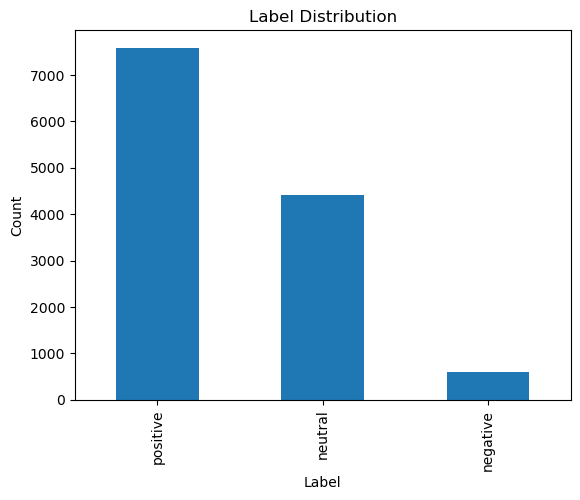

In [51]:
final_labels['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

### Xử lý dữ liệu text

In [53]:
text_files = []

for file in os.listdir(data_dir):
    if file.endswith(".txt"):
        text_files.append(os.path.join(data_dir, file))

text_files[:5]

['dataset/data/11303.txt',
 'dataset/data/3644.txt',
 'dataset/data/19987.txt',
 'dataset/data/18441.txt',
 'dataset/data/5235.txt']

In [54]:
texts = []

for txt_path in text_files:
    with open(txt_path, "r", encoding="utf-8") as f:
        content = f.read().strip()
        id = os.path.basename(txt_path).split(".")[0]
        texts.append((id, content))

texts[:5]

[('11303',
  'Excited to be hosting #crowdfunding 101 workshop in this incredible space tmrw #string #ignitefestyeg @AlbertaBoostR'),
 ('3644',
  'Showing our Green #pride at #CapitalPride – Happy Pride Everyone! #elxn42 #GPC #prideottawa'),
 ('19987',
  'After 118 consecutive hours of dewpoint &gt;= 18?, #Ottawa broke free from the humidity at 4AM today. 6th longest ever.'),
 ('18441',
  'Come in - Metro Bonaventure Station @Montreal #Montreal #mtl #underground #streetphotography'),
 ('5235',
  '#Hair and #Makeup for Actress #SuzanneClément @maisonbirks tribute #maisonbirks #birkstribute #tiff15 ??georgepimentel')]

In [55]:
print(len(texts))

19600


In [56]:
def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = text.strip()
    return text

In [57]:
texts = [(id, clean_text(text)) for id, text in texts]
texts[:5]

[('11303',
  'Excited to be hosting #crowdfunding 101 workshop in this incredible space tmrw #string #ignitefestyeg @AlbertaBoostR'),
 ('3644',
  'Showing our Green #pride at #CapitalPride – Happy Pride Everyone! #elxn42 #GPC #prideottawa'),
 ('19987',
  'After 118 consecutive hours of dewpoint &gt;= 18?, #Ottawa broke free from the humidity at 4AM today. 6th longest ever.'),
 ('18441',
  'Come in - Metro Bonaventure Station @Montreal #Montreal #mtl #underground #streetphotography'),
 ('5235',
  '#Hair and #Makeup for Actress #SuzanneClément @maisonbirks tribute #maisonbirks #birkstribute #tiff15 ??georgepimentel')]

In [58]:
df_text = pd.DataFrame(texts, columns=["ID", "text"])

In [59]:
df_text["ID"] = df_text["ID"].astype(int)
final_labels["ID"] = final_labels["ID"].astype(int)

/var/folders/jx/wkzjbxgx3t3dz139htmjzsyh0000gn/T/ipykernel_36764/953557718.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_labels["ID"] = final_labels["ID"].astype(int)


In [64]:
df = df_text.merge(final_labels, on="ID", how="right")

In [65]:
df.head()

,ID,text,label
0,2499,Knocked doors with the venerable #TeamTrudeau ...,positive
1,2502,"""""I think it's time for change"""" - Ana Commit ...",positive
2,2506,Vote for NDP is vote for another Harper. #elxn...,neutral
3,2509,…this particular government – led by this part...,negative
4,2510,This year I'm voting Alliance. #Elxn42,neutral


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12599 entries, 0 to 12598
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      12599 non-null  int64 
 1   text    12599 non-null  object
 2   label   12599 non-null  object
dtypes: int64(1), object(2)
memory usage: 295.4+ KB


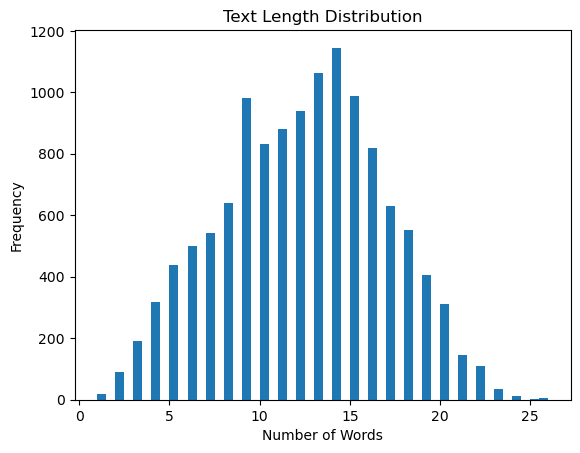

In [32]:
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

plt.hist(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

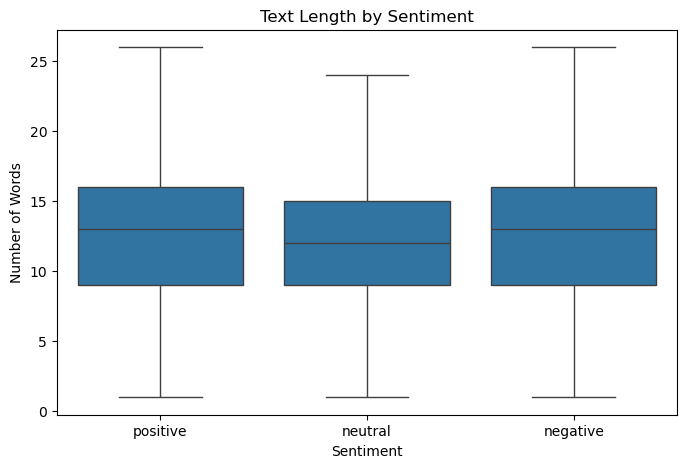

In [35]:
# Boxplot text length theo từng label
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='text_length')
plt.title("Text Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")
plt.show()

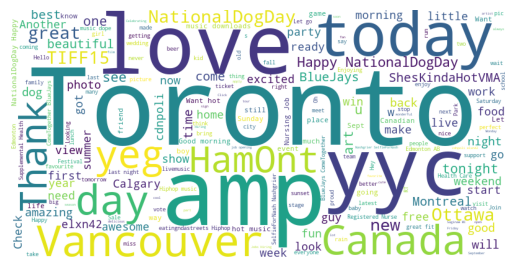

In [89]:
positive_text = " ".join(df[df['label']=="positive"]['text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

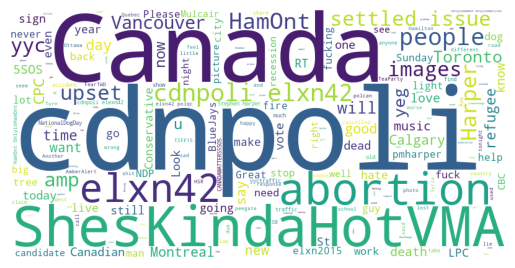

In [90]:
negative_text = " ".join(df[df['label']=="negative"]['text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

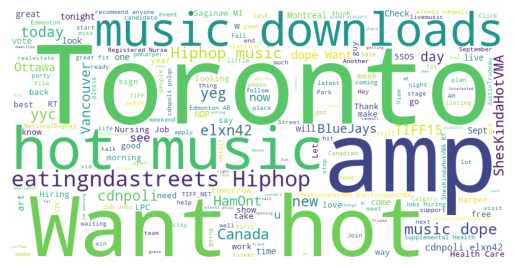

In [91]:
neutral_text = " ".join(df[df['label']=="neutral"]['text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(neutral_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [39]:
all_words = " ".join(df['text']).split()
counter = Counter(all_words)

counter.most_common(10)

[('the', 3245),
 ('to', 2710),
 ('in', 2176),
 ('a', 1910),
 ('for', 1868),
 ('of', 1644),
 ('at', 1460),
 ('on', 1327),
 ('and', 1295),
 ('is', 1133)]

### Xử lý dữ liệu image

In [67]:
image_files = []

for file in os.listdir(data_dir):
    if file.endswith((".jpg", ".png", ".jpeg")):
        id = int(os.path.basename(file).split(".")[0])
        image_files.append((id, os.path.join(data_dir, file)))

df_image = pd.DataFrame(image_files, columns=["ID", "image_path"])

# Merge vào df chính
df = df.merge(df_image, on="ID", how="left")
df.head()

,ID,text,label,image_path
0,2499,Knocked doors with the venerable #TeamTrudeau ...,positive,dataset/data/2499.jpg
1,2502,"""""I think it's time for change"""" - Ana Commit ...",positive,dataset/data/2502.jpg
2,2506,Vote for NDP is vote for another Harper. #elxn...,neutral,dataset/data/2506.jpg
3,2509,…this particular government – led by this part...,negative,dataset/data/2509.jpg
4,2510,This year I'm voting Alliance. #Elxn42,neutral,dataset/data/2510.jpg


In [74]:
def transform_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))
        
    # transform = transforms.Compose([
    #     transforms.ToTensor(),
    #     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    # ])
    
    return image

Positive Sample Images:


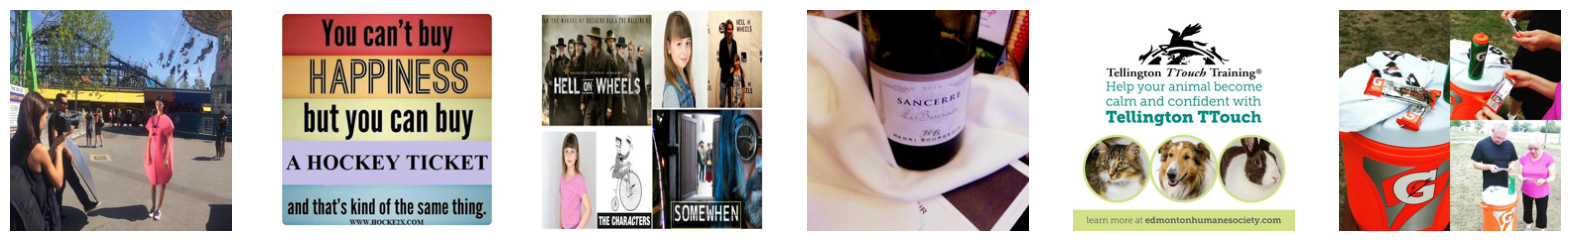

In [88]:
positive_images = df[df['label'] == "positive"]['image_path'].tolist()

rows = 1
colums = 6
fig, axes = plt.subplots(rows, colums, figsize=(20, 4))
print('Positive Sample Images:')
for i in range(colums):
    index = random.randint(0, len(positive_images)-1)
    img = transform_image(positive_images[index])
    axes[i].imshow(img)
    axes[i].axis('off')
plt.show()

Negative Sample Images:


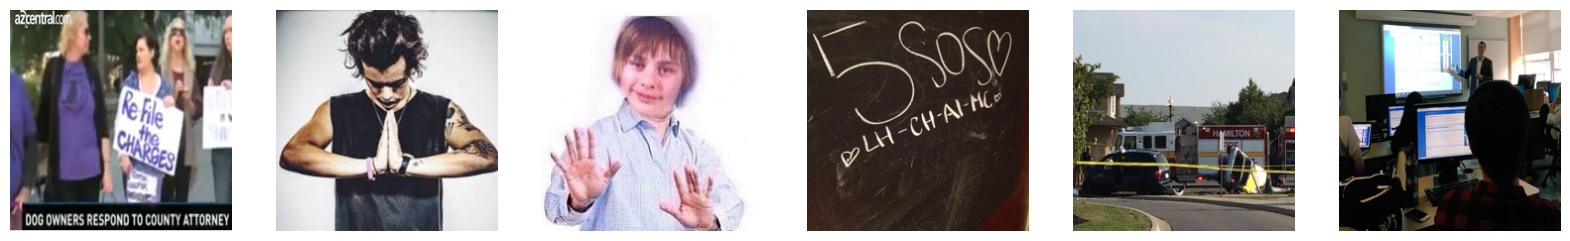

In [87]:
negative_images = df[df['label'] == "negative"]['image_path'].tolist()

rows = 1
colums = 6
fig, axes = plt.subplots(rows, colums, figsize=(20, 4))
print('Negative Sample Images:')
for i in range(colums):
    index = random.randint(0, len(negative_images)-1)
    img = transform_image(negative_images[index])
    axes[i].imshow(img)
    axes[i].axis('off')
plt.show()

Neutral Sample Images:


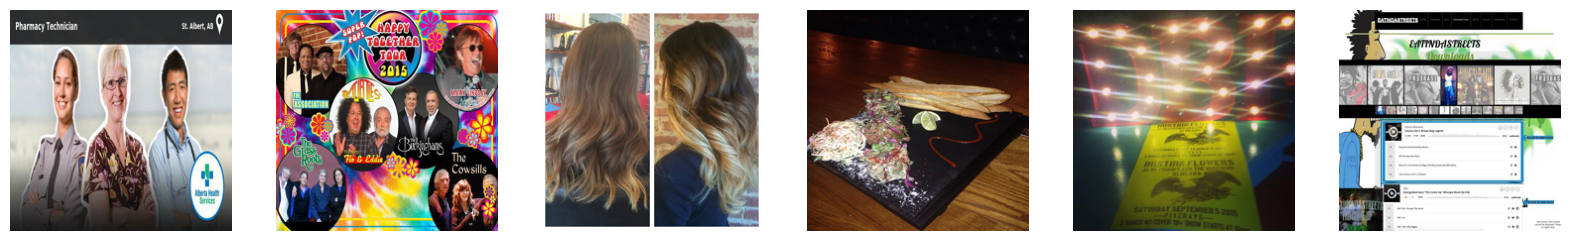

In [85]:
neutral_images = df[df['label'] == "neutral"]['image_path'].tolist()

rows = 1
colums = 6
fig, axes = plt.subplots(rows, colums, figsize=(20, 4))
print('Neutral Sample Images:')
for i in range(colums):
    index = random.randint(0, len(neutral_images)-1)
    img = transform_image(neutral_images[index])
    axes[i].imshow(img)
    axes[i].axis('off')
plt.show()